# Clustering on ECG data

With the following code we want to discover possible clusters in a dataset that contains temporal series of data, in which every row corresponds to the temporal evolution of the heartbeats. The goal is to distinguish cases according to the patient's pathology.

## 1 - Importing of libraries

Here we got all the libraries used in the project:
* matplotlib : used to create graphs to visually interpret data 
* numpy : to manipulate vectors
* pandas : to manage dataframes
* sktime.datasets : used to load the dataset in python from the .ts files
* sklearn.metrics : metrics used to evaluate the accuracy of the obtained results
* fastdtw : calculates the approximate distance between two time series and the optimal path for aligning them (DTW method)
* tslearn.clustering : to implement the KernelKMeans algorithm
* seaborn : raphical customization of Matplotlib charts

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sktime.datasets import load_from_tsfile

from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score

from fastdtw import fastdtw

from tslearn.clustering import KernelKMeans

import seaborn as sns
sns.set_theme(style="whitegrid")
sns.set_palette("muted")
%matplotlib inline

## 2 - Loading of the datasets
We have two datasets, one for the training and the other for the test, each of them has the labels.

In [28]:
K = 10
N_ITER = 10

x_train, y_train = load_from_tsfile(
    "ECG5000_TRAIN.ts",
    return_data_type = "numpy2d"
)

x_test, y_test = load_from_tsfile(
    "ECG5000_TEST.ts",
    return_data_type = "numpy2d"
)

print(f"Dataset shape x: {x_train.shape}")
print(f"Dataset shape y: {y_train.shape}")

Dataset shape x: (500, 140)
Dataset shape y: (500,)


## 3 - Data Selection

target
1    292
2    177
4     19
3     10
5      2
Name: count, dtype: int64


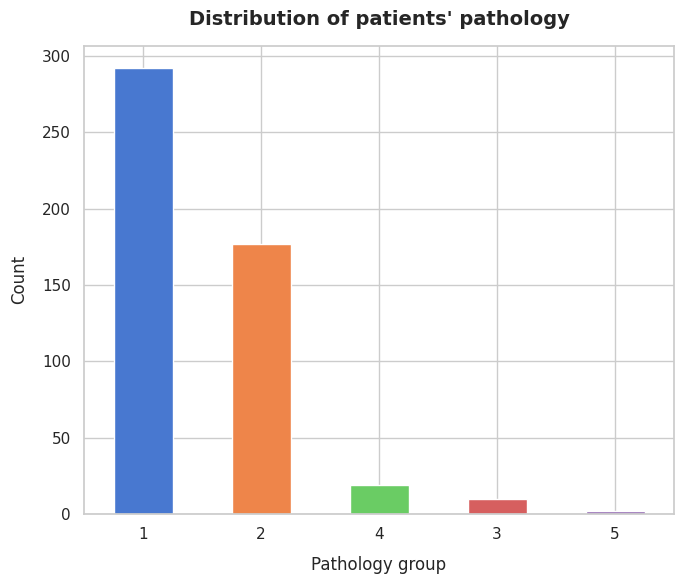

In [29]:
df = pd.DataFrame(x_train)
df["target"] = y_train
df.head(10)

print(df['target'].value_counts())

fig, ax = plt.subplots(figsize=(7, 6))
num_classi = len(df['target'].unique())
colori_muted = sns.color_palette("muted", num_classi)
df['target'].value_counts().plot(kind='bar', color=colori_muted, ax=ax)
ax.set_title("Distribution of patients' pathology", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Pathology group', fontsize=12, labelpad=10)
ax.set_ylabel('Count', fontsize=12, labelpad=10)
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
plt.show()

## 4 - KMeans
Let's proceed by drawing lots for the starting centroids. We use the seed to always have the same starting point in the future executions of the code.

In [30]:
rng = np.random.default_rng(seed=33)
representatives_index = rng.choice(x_train.shape[0], size=K, replace=False)
representatives = x_train[representatives_index].copy()
print(f"Extracted indexes : {representatives_index}")
print(f"Extracted representatives : {representatives}")

Extracted indexes : [411 264 431 218 294 149 450 126 280 187]
Extracted representatives : [[ 0.61192836  0.28295422  0.35185047 ... -0.05151126  0.45186613
   1.4743011 ]
 [-1.0523677  -1.9308342  -2.6167366  ... -2.2372133  -1.3756125
  -1.3940508 ]
 [ 0.12247472 -0.34038575 -1.121472   ... -4.3420749  -3.5555604
  -2.3502395 ]
 ...
 [ 0.4066104  -2.0084     -3.9735492  ...  1.782985    1.5594622
  -0.58660646]
 [ 0.88651199 -0.48871125 -1.4491906  ...  1.5689947   2.1902486
   1.2585758 ]
 [-2.1191075  -3.0261182  -3.2929295  ...  0.21955088 -0.19777673
  -1.161151  ]]


Cicle to obtain the clusters.

Convergence achieved after 1 iterations!!!
Convergence achieved after 2 iterations!!!
Convergence achieved after 3 iterations!!!
Convergence achieved after 4 iterations!!!
Convergence achieved after 5 iterations!!!
Convergence achieved after 6 iterations!!!
Convergence achieved after 7 iterations!!!
Convergence achieved after 8 iterations!!!
Convergence achieved after 9 iterations!!!
Convergence achieved after 2 iterations!!!
Convergence achieved after 3 iterations!!!
Convergence achieved after 4 iterations!!!
Convergence achieved after 5 iterations!!!
Convergence achieved after 6 iterations!!!
Convergence achieved after 7 iterations!!!
Convergence achieved after 8 iterations!!!
Convergence achieved after 9 iterations!!!
Convergence achieved after 7 iterations!!!
Convergence achieved after 8 iterations!!!
Convergence achieved after 9 iterations!!!


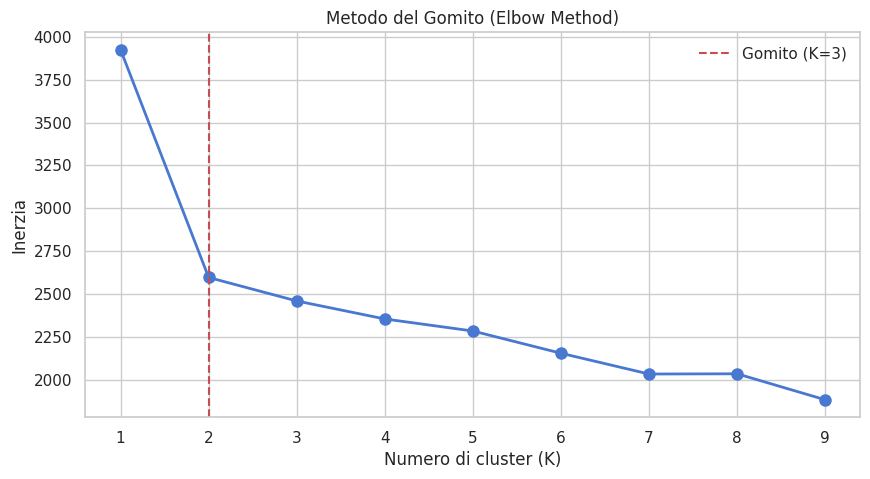

In [34]:
def dist(diff):
    return np.sqrt(np.sum(diff**2, axis=1))

def kMeans(K_k, rrepresentatives):
    inertia = 0.0
    for num_iterations in range(N_ITER):
        old_representatives = rrepresentatives.copy()
        labels = np.zeros(x_train.shape[0], dtype=int)
        current_inertia = 0.0
        for i in range(x_train.shape[0]):
            distances = dist(rrepresentatives-x_train[i])
            labels[i] = np.argmin(distances)
            min_distance = distances[labels[i]]
            current_inertia += min_distance

        for k in range(K_k):
            cluster_points = x_train[labels==k]
            if len(cluster_points) > 0:
                rrepresentatives[k] = np.mean(cluster_points, axis=0)
        
        inertia = current_inertia
        
        if np.all(old_representatives == rrepresentatives):
            print(f"Convergence achieved after {num_iterations} iterations!!!")
    
    return labels, rrepresentatives, inertia      

inertia_vec = []
for K_k in range(1, K):
    representatives_index = rng.choice(x_train.shape[0], size=K_k, replace=False)
    representatives = x_train[representatives_index].copy()
    _, _, inertia = kMeans(K_k, representatives)
    inertia_vec.append(inertia)

plt.figure(figsize=(10, 5))
plt.plot(range(1, K), inertia_vec, 'o-', linewidth=2, markersize=8)
plt.axvline(x=2, color='r', linestyle='--', label='Gomito (K=3)')
plt.xlabel('Numero di cluster (K)')
plt.ylabel('Inerzia')
plt.title('Metodo del Gomito (Elbow Method)')
plt.xticks(range(1, K))
plt.legend()
plt.grid(True)
plt.show()

K = 2

Plotting the graphs of each cluster to display the differnce betweem them. We can see that the obtained results are not optimal due to the impossibility of the Euclidean mean to catch the temporal shifting of signals.

Convergence achieved after 4 iterations!!!
Convergence achieved after 5 iterations!!!
Convergence achieved after 6 iterations!!!
Convergence achieved after 7 iterations!!!
Convergence achieved after 8 iterations!!!
Convergence achieved after 9 iterations!!!


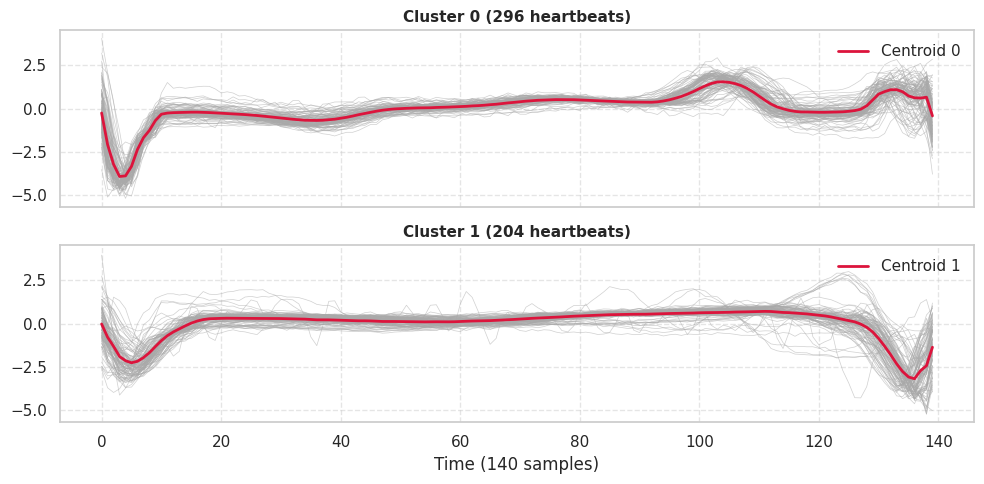

In [35]:
representatives_index = rng.choice(x_train.shape[0], size=K, replace=False)
representatives = x_train[representatives_index].copy()
labels, representatives, inertia = kMeans(K, representatives)

fig, axes = plt.subplots(K, 1, figsize=(10, 2.5 * K), sharex=True, sharey=True)
MAX_CURVES = 100
for k in range(K):
    cluster_signals = x_train[labels == k]
    ax = axes[k]
    for signal in cluster_signals[:MAX_CURVES]:
        ax.plot(signal, color='darkgray', alpha=0.55, linewidth=0.5)
    
    ax.plot(representatives[k], color='crimson', linewidth=2, label=f'Centroid {k}')
    ax.set_title(f"Cluster {k} ({len(cluster_signals)} heartbeats)", fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

plt.xlabel("Time (140 samples)")
plt.tight_layout()
plt.show()

Using sklearn to analayze the results. The value returned is clipped between -1 and +1.

In [36]:
sil = silhouette_score(x_train, labels)
cal = calinski_harabasz_score(x_train, labels)
print(f"Silhouette Global Score : {sil:.3f}")
print(f"Calinski Harabasz Global Score : {cal:.3f}")

Silhouette Global Score : 0.466
Calinski Harabasz Global Score : 507.017


Using testset to evaluate the results.

In [ ]:
def kmeans_testing():
    test_labels = np.zeros(x_test.shape[0], dtype=int)
    for i in range(x_test.shape[0]):
        test_labels[i] = np.argmin(dist(representatives-x_test[i]))
    return test_labels

ari_score = adjusted_rand_score(y_test, kmeans_testing())
print(f"Clustering quality on Test Set (ARI): {ari_score:.3f}")

Clustering quality on Test Set (ARI): 0.453


In [34]:
np.savez("risultati_kmeans.npz", x_train=x_train, labels=labels, representatives=representatives)

Now we can try to process data with another algorithm in order to catch a more precise cluseter identification. For this reason we use the Dynamic Time Warping (DTW). In the STEP 1 we assign every time-series to a representative based on the fastdtw value that returns the dtw distance between the representative and the series.
In the STEP 2 we have the main difference between the K-means and DTW, in facts, we use the old centroids of each cluster and identify the similarity with the other series of the cluster. In this way we obtain a path that tracks the associations in time between the old centroid and the other series and using this we move the centroid towards the series that have a greater similarity with the old centroid. This dynamic barycenter technique is called DBA (DTW Barycenter Averaging).

In [ ]:
N, L = x_train.shape

rng = np.random.default_rng(seed=34)
representatives = x_train[rng.choice(N, K, replace=False)]

labels = np.zeros(N, dtype=int)

max_iter = 10

def dba_update_custom(cluster_points, old_representative):
    centroid_sum = np.zeros(L)
    centroid_count = np.zeros(L)

    for point in cluster_points:
        _, path = fastdtw(old_representative, point, dist=lambda x, y: (x - y)**2)
        for t_old_centroid, t_point in path:
            centroid_sum[t_old_centroid] += point[t_point]
            centroid_count[t_old_centroid] += 1
    
    centroid_count[centroid_count==0] = 1
    
    return centroid_sum/centroid_count


for iteration in range(max_iter):
    # STEP 1 : assignment
    new_labels = np.zeros(N, dtype=int)
    for i in range(N):
        distances = []
        for k in range(K):
            dist, _ = fastdtw(x_train[i], representatives[k], dist=lambda x, y: (x - y)**2)
            distances.append(dist)
        new_labels[i] = np.argmin(distances)
    
    # convergence verification
    if np.all(new_labels==labels):
        break
    labels = new_labels.copy()

    # STEP 2 : recalculation of representatives (DBA)
    for k in range(K):
        cluster_points = x_train[labels==k]
        if len(cluster_points) > 0:
            representatives[k] = dba_update_custom(cluster_points, representatives[k])
    print(f"Iteration {iteration+1}/{max_iter} completed.")

Iteration 1/10 completed.
Iteration 2/10 completed.
Iteration 3/10 completed.
Iteration 4/10 completed.
Iteration 5/10 completed.
Iteration 6/10 completed.
Iteration 7/10 completed.
Iteration 8/10 completed.
Iteration 9/10 completed.
Iteration 10/10 completed.


The following graphs do not represent a correct visualization of the results and just shows the differnce with the k-means.

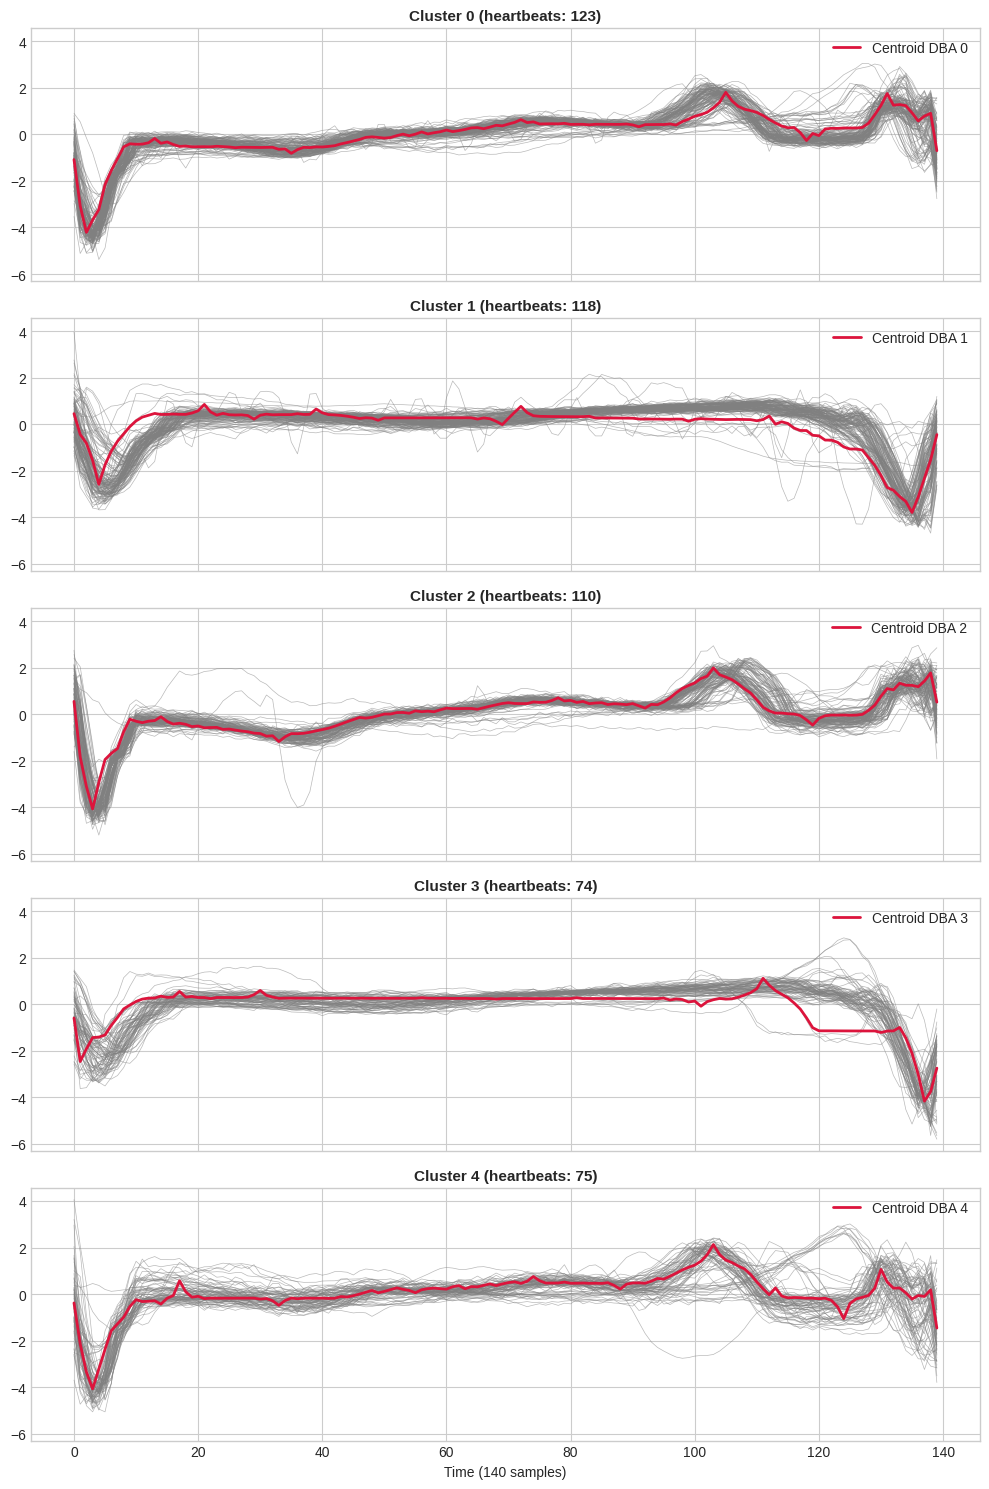

In [36]:
plt.style.use('seaborn-v0_8-whitegrid') # se dà errore usa 'default'

fig, axes = plt.subplots(K, 1, figsize=(10, 3 * K), sharex=True, sharey=True)

for k in range(K):
    cluster_signals = x_train[labels == k]
    for signal in cluster_signals:
        axes[k].plot(signal, color='gray', alpha=0.55, linewidth=0.5)
    axes[k].plot(representatives[k], color='crimson', linewidth=2, label=f'Centroid DBA {k}')
    axes[k].set_title(f'Cluster {k} (heartbeats: {len(cluster_signals)})', fontsize=11, fontweight='bold')
    axes[k].legend(loc='upper right')

axes[-1].set_xlabel('Time (140 samples)')
plt.tight_layout()
plt.show()

Here is a way to see the path associations between the centroid and a single series taken from it.

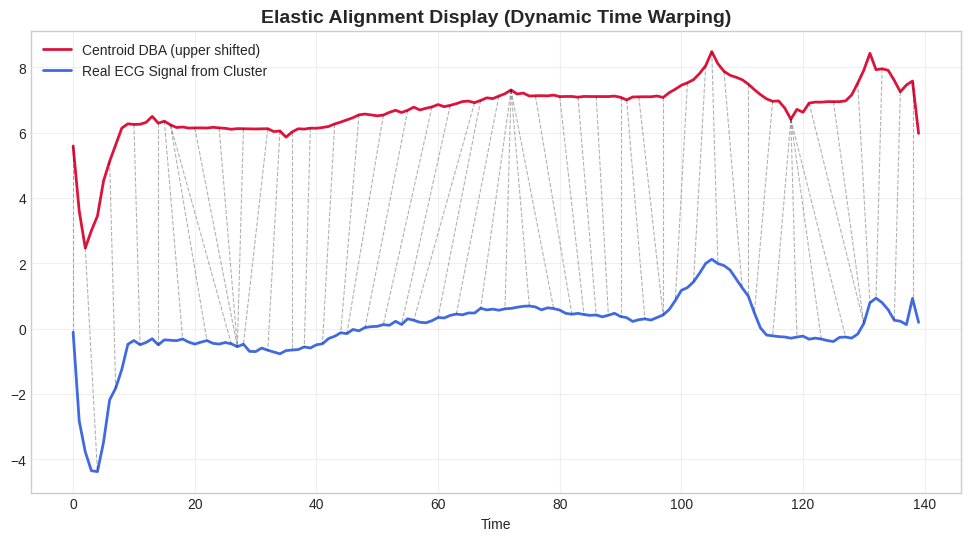

In [37]:
# we take just the first cluster and the first signal of teh cluster
target_cluster = 0
signals_cluster = x_train[labels == target_cluster]

if len(signals_cluster) > 0:
    segnale_esempio = signals_cluster[0]
    centroide_esempio = representatives[target_cluster]

    _, path = fastdtw(centroide_esempio, segnale_esempio, dist=lambda x, y: (x - y)**2)

    plt.figure(figsize=(12, 6))
    
    offset = np.max(centroide_esempio) - np.min(segnale_esempio) + 0.5
    
    plt.plot(centroide_esempio + offset, color='crimson', linewidth=2, label='Centroid DBA (upper shifted)')
    plt.plot(segnale_esempio, color='royalblue', linewidth=2, label='Real ECG Signal from Cluster')

    for t_bary, t_sig in path[::4]:
        plt.plot([t_bary, t_sig], [centroide_esempio[t_bary] + offset, segnale_esempio[t_sig]], 
                 color='black', linestyle='--', alpha=0.3, linewidth=0.8)

    plt.title("Elastic Alignment Display (Dynamic Time Warping)", fontsize=14, fontweight='bold')
    plt.xlabel("Time")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print(f"The cluster {target_cluster} is empty.")

This script calculates the Silhouette Score for a DTW algorithm

In [ ]:
n_eval = min(300, len(x_train))
X_eval = x_train[:n_eval]
labels_eval = labels[:n_eval]

dtw_dist_matrix = np.zeros((n_eval, n_eval))
for i in range(n_eval):
    for j in range(i+1, n_eval):
        d, _ = fastdtw(X_eval[i].ravel(), X_eval[j].ravel(), dist=lambda x, y: (x - y)**2)
        dtw_dist_matrix[i, j] = d
        dtw_dist_matrix[j, i] = d

true_dtw_silhouette = silhouette_score(dtw_dist_matrix, labels_eval, metric='precomputed')
print(f"Silhouette with DTW metric: {true_dtw_silhouette:.3f}")

Silhouette with DTW metric: 0.252


In [39]:
def dtw_testing():
    test_labels = np.zeros(x_test.shape[0], dtype=int)
    for i in range(x_test.shape[0]):
        distances = []
        for k in range(K):
            dist, _ = fastdtw(x_test[i], representatives[k], dist=lambda x, y: (x - y)**2)
            distances.append(dist)
        test_labels[i] = np.argmin(distances)
    return test_labels

ari_score = adjusted_rand_score(y_test, dtw_testing())
print(f"Clustering quality on Test Set (ARI): {ari_score:.3f}")

Clustering quality on Test Set (ARI): 0.329


In [41]:

np.savez("risultati_DTW_euclidean.npz", x_train=x_train, labels=labels, representatives=representatives)

To achive a better result we can try with the Kernel K-Means. In kernel k-means is not possible to estblish the position of centroids

In [11]:
from tslearn.clustering import KernelKMeans
from sklearn.metrics import adjusted_rand_score
import numpy as np
from sktime.datasets import load_from_tsfile

K = 5
N_ITER = 20

x_train, y_train = load_from_tsfile(
    "ECG5000_TRAIN.ts",
    return_data_type = "numpy2d"
)

x_test, y_test = load_from_tsfile(
    "ECG5000_TEST.ts",
    return_data_type = "numpy2d"
)

x_train_ts = np.expand_dims(x_train, axis=2)
x_test_ts = np.expand_dims(x_test, axis=2)

kernel_kmeans = KernelKMeans(
    n_clusters = K,
    kernel = "gak",
    kernel_params={"sigma": 5.0},
    max_iter = N_ITER,
    random_state = 34,
    n_jobs = -1
)

train_labels_kernel = kernel_kmeans.fit_predict(x_train_ts)

test_labels_kernel = kernel_kmeans.predict(x_test_ts)

ari_score_kernel = adjusted_rand_score(y_test, test_labels_kernel)

print(f"Clustering quality on Test Set (ARI): {ari_score_kernel:.3f}")

Clustering quality on Test Set (ARI): 0.554
